Price Optimization: Overview
Price optimization is a strategic approach that uses data collection on sales, costs, competition, and market trends to predict demand changes and analyze price elasticity, which enables businesses to set optimal prices. It involves competitive analysis to monitor market positioning, customer segmentation to identify varying willingness to pay, and the use of mathematical optimization algorithms to determine the best price points.

To get started with the task of Price Optimization, we need a dataset based on sales, costs, competition, and market trends. I found an ideal dataset for this task which contains features like:

Fiscal_Week_Id: The fiscal week identifier.
Store_Id: The store identifier.
Item_Id: The item identifier.
Price: The price of the item at our store.
Item_Quantity: The quantity of the item sold.
Sales_Amount_No_Discount: Sales amount without discount.
Sales_Amount: Sales amount after discounts.
Competition_Price: The price of the item at a competing store.

In [75]:
import pandas as pd 
import matplotlib.pyplot as plt

In [76]:
com_data = pd.read_csv("Competition_Data.csv")
com_data.head()

,Index,Fiscal_Week_ID,Store_ID,Item_ID,Price,Item_Quantity,Sales_Amount_No_Discount,Sales_Amount,Competition_Price
0,0,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,206.44
1,1,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,158.01
2,2,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,278.03
3,3,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,222.66
4,4,2019-11,store_459,item_526,134.49,435,4716.74,11272.59,195.32


In [77]:
com_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Index                     100000 non-null  int64  
 1   Fiscal_Week_ID            100000 non-null  object 
 2   Store_ID                  100000 non-null  object 
 3   Item_ID                   100000 non-null  object 
 4   Price                     100000 non-null  float64
 5   Item_Quantity             100000 non-null  int64  
 6   Sales_Amount_No_Discount  100000 non-null  float64
 7   Sales_Amount              100000 non-null  float64
 8   Competition_Price         100000 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 6.9+ MB


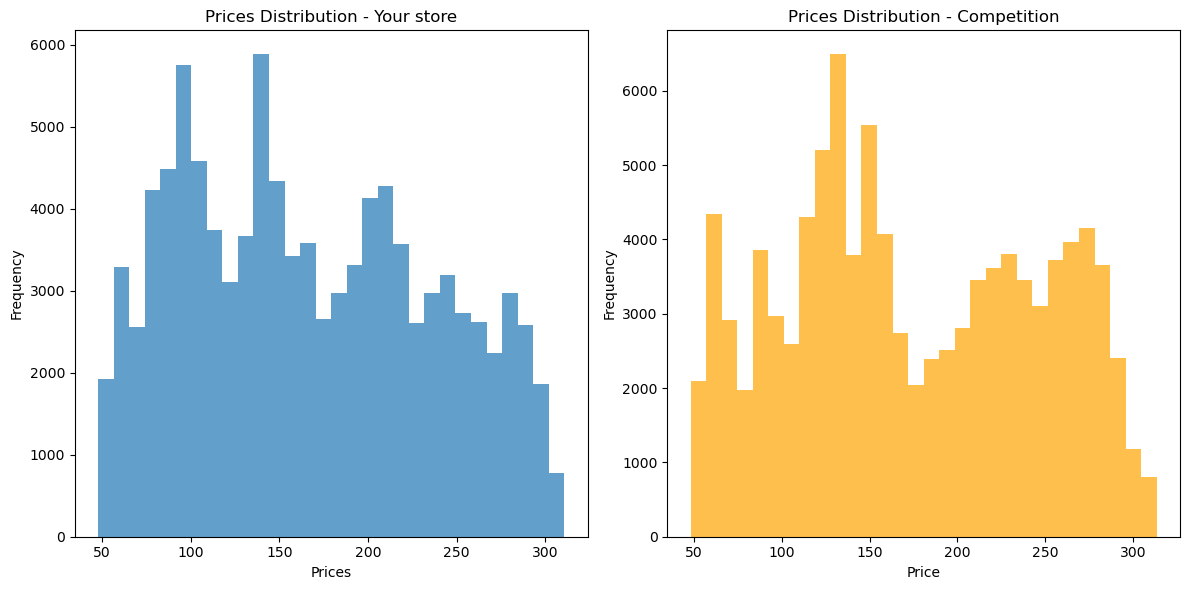

In [78]:
#comparing the prices distribution with competition 
plt.figure(figsize = (12,6)) 

plt.subplot(1,2,1)
plt.hist(com_data["Price"], bins = 30, alpha = 0.7, label = "Your Store")
plt.xlabel("Prices")
plt.ylabel("Frequency")
plt.title("Prices Distribution - Your store")

plt.subplot(1,2,2)
plt.hist(com_data["Competition_Price"], bins = 30, alpha = 0.7, label = "Competition", color = "orange")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Prices Distribution - Competition")

plt.tight_layout()

plt.show()
         

It shows that the competition’s prices are generally higher, with peaks around the 100-150 and 200-250 price ranges, which indicate a concentration of higher-priced items. In contrast, our store’s prices are more evenly distributed across the 50-300 range, with notable peaks around 100-150.

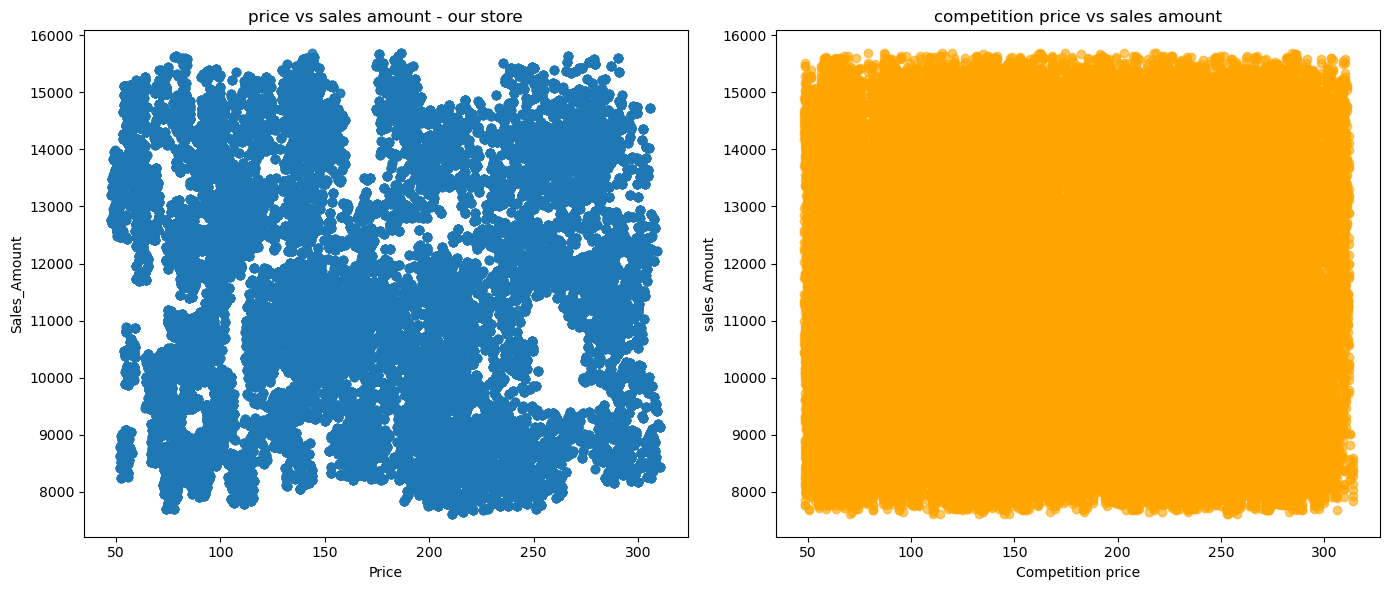

In [80]:
##compare the relationship between price and sale

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.scatter(com_data["Price"], com_data["Sales_Amount"], alpha = 0.6, label = "Your Store")
plt.xlabel("Price")
plt.ylabel("Sales_Amount")
plt.title("price vs sales amount - our store")

plt.subplot(1,2,2)

plt.scatter(com_data["Competition_Price"], com_data["Sales_Amount"], alpha = 0.6, color = "orange", label = "Competition")
plt.xlabel("Competition price")
plt.ylabel("sales Amount")
plt.title("competition price vs sales amount")

plt.tight_layout()

plt.show()
            

The scatter plots compare the relationship between price and sales amount for our store (left) and the competition (right). For our store, the plot shows a wide dispersion of sales amounts across various price points, which indicates varied performance in different price ranges without a clear trend. In contrast, the competition’s plot shows a dense clustering of sales amounts around higher values, with prices also spread across a similar range but demonstrating a more consistent sales performance. It suggests that the competition might have a more effective pricing strategy, which maintains higher sales amounts more uniformly across different price points.

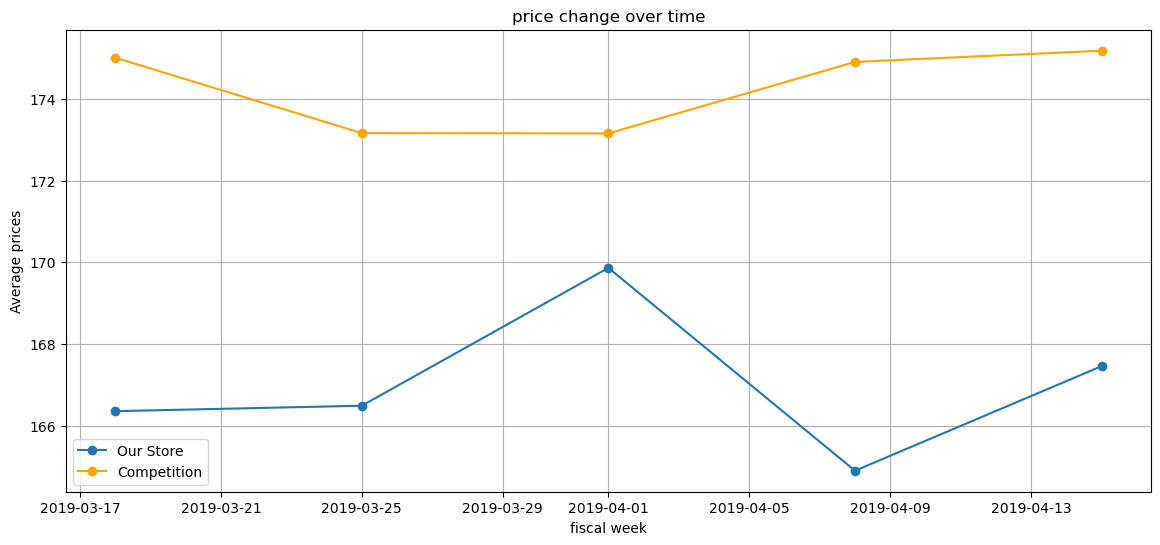

In [82]:
##price change over time 
com_data["Fiscal_Week_ID"] = pd.to_datetime(com_data["Fiscal_Week_ID"].astype(str) + "-1", format="%Y-%W-%w")


weekly_prices = com_data.groupby("Fiscal_Week_ID").agg({"Price":"mean","Competition_Price":"mean"}).reset_index()

plt.figure(figsize = (14,6))

plt.plot(weekly_prices["Fiscal_Week_ID"],weekly_prices["Price"],label = "Our Store", marker = "o")
plt.plot(weekly_prices["Fiscal_Week_ID"],weekly_prices["Competition_Price"],label = "Competition",marker = "o",color="orange")

plt.xlabel("fiscal week")
plt.ylabel("Average prices")
plt.title("price change over time")
plt.legend()
plt.grid(True)

plt.show()



The competition maintains higher average prices consistently above 170, with a slight upward trend over the observed weeks. In contrast, our store’s prices start around 166, increase slightly, then dip before rising again. It indicates that the competition follows a more stable pricing strategy, while our store experiences more fluctuations in pricing. The stability in the competition’s pricing could be contributing to their higher and more consistent sales performance.

C:\Users\DELL\AppData\Local\Temp\ipykernel_5260\1275627535.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


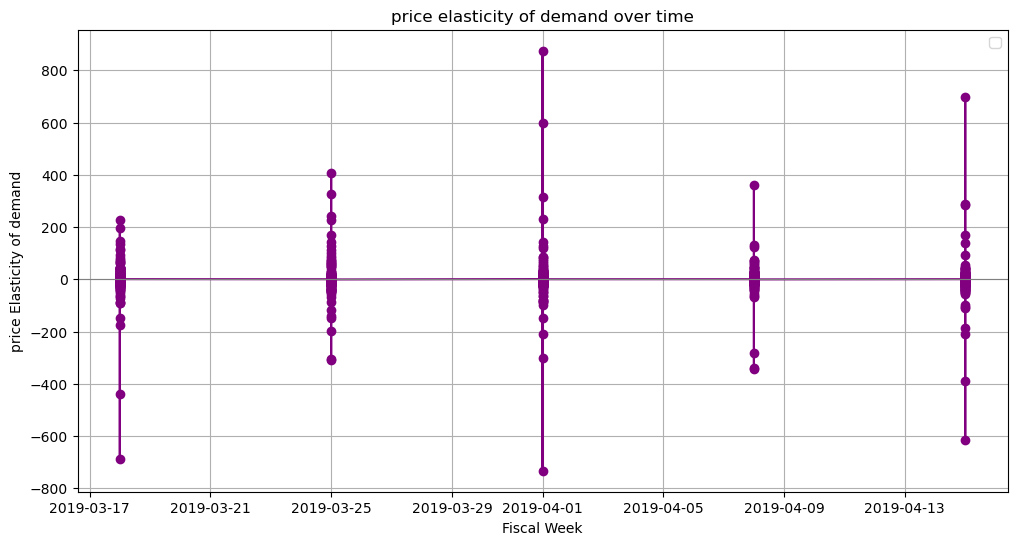

In [84]:
##calculate change in price and how it affects change in quantity sold, for this we need to calculate price elasticity 
#ED = % change in quantity demand / % change in price 
com_data["price_change"] = com_data["Price"].pct_change()
com_data["qty_change"] = com_data["Item_Quantity"].pct_change()

com_data["Elasticity"] = com_data["qty_change"] / com_data["price_change"]

com_data.replace ([float("inf") - float("inf")], float("nan"), inplace=True)
com_data.dropna (subset = ["Elasticity"], inplace= True)

plt.figure(figsize = (12,6))
plt.plot(com_data["Fiscal_Week_ID"], com_data["Elasticity"],marker = "o", linestyle = "-", color = "purple")
plt.axhline(0, color = "grey", linewidth = 0.8)
plt.xlabel("Fiscal Week")
plt.ylabel("price Elasticity of demand")
plt.title("price elasticity of demand over time")
plt.legend()
plt.grid(True)

plt.show()



C:\Users\DELL\AppData\Local\Temp\ipykernel_5260\2411489908.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


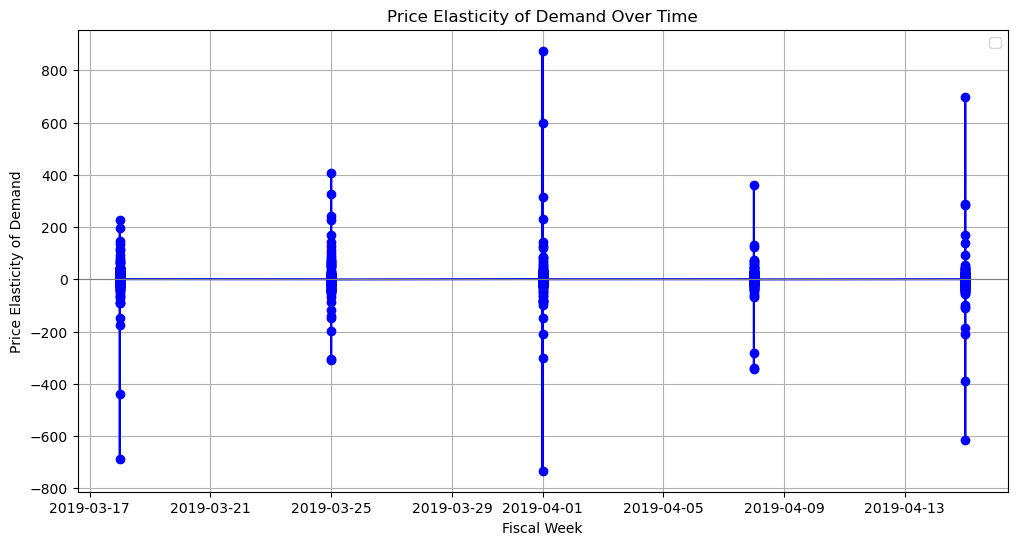

In [85]:
#Calculate Price Elasticity

# Calculate percentage change in price and quantity
com_data["price_change"] = com_data["Price"].pct_change()
com_data["qty_change"] = com_data["Item_Quantity"].pct_change()

# Calculate price elasticity of demand
com_data["Elasticity"] = com_data["qty_change"] / com_data["price_change"]

# Replace infinite values with NaN and drop rows with missing elasticity values
com_data.replace([float("inf"), -float("inf")], float("nan"), inplace=True)
com_data.dropna(subset=["Elasticity"], inplace=True)


#Visualize Price Elasticity Over Time

# Create a line plot of price elasticity over time
plt.figure(figsize=(12,6))
plt.plot(com_data["Fiscal_Week_ID"], com_data["Elasticity"], marker="o", linestyle="-", color="blue")

# Add a horizontal line at y=0
plt.axhline(0, color="grey", linewidth=0.8)

# Set labels and title
plt.xlabel("Fiscal Week")
plt.ylabel("Price Elasticity of Demand")
plt.title("Price Elasticity of Demand Over Time")

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


The graph shows the price elasticity of demand over time. It highlights significant variability in elasticity across different weeks, with values ranging from highly negative to highly positive. It indicates that the sensitivity of quantity demanded to price changes fluctuates considerably. High positive elasticity suggests that in some weeks, demand increased significantly with price increases, while high negative elasticity in other weeks indicates a sharp drop in demand with price hikes. The broad spread of elasticity values implies an inconsistent response to price changes, which suggests that factors other than price, such as promotions, seasonality, or market conditions, might be influencing demand.

In [87]:
#Now, let’s calculate and compare the total sales amounts for our store and the competition:
total_sales_store = com_data["Sales_Amount"].sum()
total_sales_competition = (com_data["Competition_Price"] * com_data["Item_Quantity"]).sum()

total_qty_store = com_data["Item_Quantity"].sum()
total_qty_competition = com_data["Item_Quantity"].sum() 

summary = pd.DataFrame({"Metric": ["Total sales amount", "Total Quantity sold"],
                        "Your Store": [total_sales_store, total_qty_competition],
                        "Competition": [total_sales_competition, total_qty_competition]})

summary

,Metric,Your Store,Competition
0,Total sales amount,1.140889e+08,696114949.1
1,Total Quantity sold,3.984317e+06,3984317.0


Our store’s total sales amount is 114,100,500, whereas the competition’s total sales amount is 696,209,700 (assuming equal quantity sold). The competition has a significantly higher total sales amount compared to our store. It indicates that their pricing strategy is more effective in generating revenue.

Our store’s total sales amount is 114,100,500, whereas the competition’s total sales amount is 696,209,700 (assuming equal quantity sold). The competition has a significantly higher total sales amount compared to our store. It indicates that their pricing strategy is more effective in generating revenue.

In [90]:
# define price bracket
bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
labels = ["0-50","51-100","101-150","151-200","201-250","251-300","301-350","351-400","401-450","451-500"]

#create price bracket for both store and competition
com_data["price_bracket"] = pd.cut(com_data["Price"], bins = bins, labels = labels, right = False)
com_data["Competition_bracket"] = pd.cut(com_data["Competition_Price"], bins = bins, labels = labels, right = False)

# calculate sales amount by price bracket for your store
sales_by_bracket_store = com_data.groupby("price_bracket")["Sales_Amount"].sum().reset_index()
sales_by_bracket_store.columns = ["Price Bracket", "Your Store Sales Amount"]

#calculate sales amount by price bracket for competition 
com_data["Competition_sales_amt"] = com_data["Competition_Price"] * com_data["Item_Quantity"]
sales_by_bracket_com = com_data.groupby("Competition_bracket")["Competition_sales_amt"].sum().reset_index()
sales_by_bracket_com.columns = ["Price Bracket", "Competition sales amount"]

sales_by_bracket = pd.merge(sales_by_bracket_store, sales_by_bracket_com, on = "Price Bracket")

sales_by_bracket

C:\Users\DELL\AppData\Local\Temp\ipykernel_5260\2092252607.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_bracket_store = com_data.groupby("price_bracket")["Sales_Amount"].sum().reset_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_5260\2092252607.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_bracket_com = com_data.groupby("Competition_bracket")["Competition_sales_amt"].sum().reset_index()


,Price Bracket,Your Store Sales Amount,Competition sales amount
0,0-50,346800.63,9.305357e+05
1,51-100,24636244.30,4.889277e+07
2,101-150,29634123.98,1.278404e+08
3,151-200,20658418.18,1.092184e+08
4,201-250,20742288.10,1.908800e+08
5,251-300,16778087.66,2.047670e+08
6,301-350,1292959.36,1.358583e+07
7,351-400,0.00,0.000000e+00
8,401-450,0.00,0.000000e+00
9,451-500,0.00,0.000000e+00


The table shows the total sales amounts for both our store and the competition across different price brackets. Here are some key observations:


0-50 Bracket: The competition has significantly higher sales in this bracket.
51-100 Bracket: The competition outperforms our store by a wide margin.
101-150 Bracket: The competition’s sales are much higher than our store’s sales.
151-200 Bracket: The competition again has significantly higher sales.
201-250 Bracket: The competition’s sales are nearly double those of our store.
251-300 Bracket: The competition has higher sales, but the gap is smaller compared to other brackets.
301-350 Bracket: The competition has higher sales, though the overall sales amount is lower in this bracket compared to others.

Price Optimization with Dynamic Pricing
Now, let’s start by defining a dynamic pricing model and simulating its performance. Here are the steps we will use:

We will enhance our dataset to include segments and calculate price elasticity for each segment.
We’ll create segments based on purchasing behaviour and calculate price elasticity for each segment.
We’ll define dynamic pricing rules based on competitor pricing, demand, and elasticity.
We’ll simulate the dynamic pricing model and compare it with the existing pricing strategy.
Now, let’s start with segmenting the data and calculating price elasticity for each segment:

In [93]:
## segment customers based on purchasing behaviours

#calculate avearge price and total quantity sold for each item 
item_summary = com_data.groupby("Item_ID").agg({"Price":"mean", "Item_Quantity":"sum"}).reset_index()
com_data = pd.merge(com_data,item_summary, on ="Item_ID", suffixes=("","_avg"))

#define segemnts based on average price
com_data["segment"] = pd.cut(com_data["Price_avg"], bins = [0,50,150,300], labels = ["Low","Medium","High"])

#calculate price elasticity for each segments
segments = com_data["segment"].unique()
elasticity_data = []
for segment in segments:
    segment_data = com_data[com_data["segment"] == segment]
    segment_data["price_change"] = segment_data["Price"].pct_change()
    segment_data["qty_change"] = segment_data["Item_Quantity"].pct_change()
    segment_data["elasticity"] = segment_data["qty_change"]/segment_data["price_change"]
    segment_data.replace([float("inf"), -float("inf")], float("nan"), inplace = True)
    avg_elasticity = segment_data["elasticity"].mean()
    elasticity_data.append({"segment":segment, "avg_elasticity":avg_elasticity})

elasticity_df = pd.DataFrame(elasticity_data)

elasticity_df



C:\Users\DELL\AppData\Local\Temp\ipykernel_5260\653134100.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segment_data["price_change"] = segment_data["Price"].pct_change()
C:\Users\DELL\AppData\Local\Temp\ipykernel_5260\653134100.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segment_data["qty_change"] = segment_data["Item_Quantity"].pct_change()
C:\Users\DELL\AppData\Local\Temp\ipykernel_5260\653134100.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

,segment,avg_elasticity
0,Medium,0.154510
1,High,0.148043
